- Assemble the full ViT: patches + embeddings + encoder + classification head
- Train it on CIFAR-10 (50,000 images, 10 classes) in under 10 minutes
- Evaluate its predictions on unseen test images
- Visualize attention maps — where does the model look when classifying a cat vs a truck?
- Analyze position embeddings — does the model learn that patch 0 is top-left and patch 63 is bottom-right?

In [1]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: Tesla T4
   Memory: 15.6 GB

📦 Python 3.12.13
🔥 PyTorch 2.10.0+cu128
🎲 Random seed set to 42


## Pipeline

```
Image (32×32×3)
    ↓  Split into 4×4 patches
64 Patches (each 4×4×3 = 48 values)
    ↓  Linear projection to D=192
64 Patch Embeddings (each 192-dim)
    ↓  Prepend [CLS] token
65 Tokens (each 192-dim)
    ↓  Add position embeddings
65 Positioned Tokens
    ↓  Pass through 6 Transformer blocks
65 Encoded Tokens
    ↓  Extract [CLS] token (index 0)
1 Global Representation (192-dim)
    ↓  Layer Norm → Linear(192, 10)
10 Class Logits → Prediction
```



In [2]:
# Compare ViT variant sizes
variants = {
    'ViT-Tiny (ours)': {'layers': 6, 'dim': 192, 'heads': 3},
    'ViT-Base':        {'layers': 12, 'dim': 768, 'heads': 12},
    'ViT-Large':       {'layers': 24, 'dim': 1024, 'heads': 16},
    'ViT-Huge':        {'layers': 32, 'dim': 1280, 'heads': 16},
}

print(f"{'Variant':<18} {'Layers':>6} {'Dim':>6} {'Heads':>6} {'~Params':>10}")
print("-" * 50)
for name, v in variants.items():
    # Rough param estimate: ~12·D² per block + embeddings
    approx_params = v['layers'] * 12 * v['dim']**2 + v['dim'] * 197
    print(f"{name:<18} {v['layers']:>6} {v['dim']:>6} {v['heads']:>6} {approx_params/1e6:>9.1f}M")

Variant            Layers    Dim  Heads    ~Params
--------------------------------------------------
ViT-Tiny (ours)         6    192      3       2.7M
ViT-Base               12    768     12      85.1M
ViT-Large              24   1024     16     302.2M
ViT-Huge               32   1280     16     629.4M


## Section 3: The Mathematics

Let us formalize the three mathematical ideas we need for the full model.

### 3.1 The Classification Head

After the Transformer encoder processes all tokens through $L$ layers, we extract the `[CLS]` token from the final layer:

$$\hat{y} = \text{Linear}(\text{LayerNorm}(\mathbf{z}_L^0))$$

where:
- $\mathbf{z}_L^0 \in \mathbb{R}^D$ is the `[CLS]` token at layer $L$ (the superscript 0 means it is the first token)
- LayerNorm stabilizes the representation before the final projection
- Linear projects from dimension $D$ to $C$ classes (192 → 10 for CIFAR-10)

This is deliberately simple. The entire "intelligence" of the model is in the Transformer encoder; the head just reads off the answer.

### 3.2 Cross-Entropy Loss

We train with the standard classification loss:

$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$

where $y_c$ is 1 for the true class and 0 elsewhere, and $\hat{y}_c = \text{softmax}(\text{logits})_c$.

In practice, since $y$ is one-hot, this simplifies to:

$$\mathcal{L} = -\log(\hat{y}_{true})$$

The loss is just the **negative log probability** of the correct class. If the model assigns 90% probability to the right answer, the loss is $-\log(0.9) = 0.105$. If it assigns only 10%, the loss is $-\log(0.1) = 2.303$. The training process pushes all 2.8M parameters to minimize this value.

### 3.3 Parameter Count Breakdown

Let us derive exactly where our ~2.8M parameters come from (ViT-Tiny with $D=192$, $L=6$, $H=3$, patch size $P=4$, CIFAR-10 images $32 \times 32 \times 3$):

**Patch Embedding:**
- Conv2d weight: $(P^2 \cdot C) \cdot D = (16 \cdot 3) \cdot 192 = 9{,}216$ weights + 192 bias = **9,408**

**CLS Token + Position Embeddings:**
- CLS token: $1 \cdot D = 192$
- Position embeddings: $(N+1) \cdot D = 65 \cdot 192 = 12{,}480$
- Total: **12,672**

**Per Transformer Block:**
- Multi-head attention (Q, K, V projections + output): $4 \cdot D^2 + 4D = 4 \cdot 192^2 + 768 = 148{,}224$
- MLP (two linear layers with expansion ratio 4): $2 \cdot 4 \cdot D^2 + (4D + D) = 8 \cdot 192^2 + 960 = 295{,}680$
- Two LayerNorms: $2 \cdot 2D = 768$
- Per block total: **~444,672**
- Times 6 blocks: **~2,668,032**

**Final LayerNorm + Classification Head:**
- LayerNorm: $2D = 384$
- Linear: $D \cdot C + C = 192 \cdot 10 + 10 = 1{,}930$
- Total: **2,314**

**Grand total: ~2,692,426 parameters** (approximately 2.7M)

Every single one of these numbers will be adjusted during training to minimize the cross-entropy loss.

Let us verify our hand calculation with code.

In [4]:
# Verify the parameter count breakdown
D = 192          # embed_dim
L = 6            # depth
P = 4            # patch_size
C_in = 3         # channels
N = 64           # num_patches
C_out = 10       # num_classes

patch_embed_params = P * P * C_in * D + D  # Conv2d weight + bias
cls_pos_params = D + (N + 1) * D           # CLS token + position embeddings
per_block = 4 * D * D + 4 * D + 8 * D * D + (4 * D + D) + 2 * 2 * D  # attn + MLP + norms
encoder_params = L * per_block
head_params = 2 * D + D * C_out + C_out    # final LN + linear head

total = patch_embed_params + cls_pos_params + encoder_params + head_params
print(f"Patch embedding:    {patch_embed_params:>10,}")
print(f"CLS + Position:     {cls_pos_params:>10,}")
print(f"Encoder ({L} blocks): {encoder_params:>10,}")
print(f"Head:               {head_params:>10,}")
print(f"{'':->35}")
print(f"Estimated total:    {total:>10,}")
print(f"\n(Actual count will be close but may differ")
print(f" slightly due to bias terms in nn.MultiheadAttention)")

Patch embedding:         9,408
CLS + Position:         12,672
Encoder (6 blocks):  2,669,184
Head:                    2,314
-----------------------------------
Estimated total:     2,693,578

(Actual count will be close but may differ
 slightly due to bias terms in nn.MultiheadAttention)


In [3]:
# Install and import everything we need
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Dataset

In [4]:
# CIFAR-10 class names
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Training transforms: augmentation + normalization
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    ),
])

# Test transforms: normalization only (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    ),
])

In [5]:
# Download and load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"Training batches:   {len(train_loader)}")
print(f"Test batches:       {len(test_loader)}")
print(f"Classes:            {CIFAR10_CLASSES}")

100%|██████████| 170M/170M [00:05<00:00, 28.9MB/s]


Training samples:   50,000
Test samples:       10,000
Training batches:   391
Test batches:       79
Classes:            ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


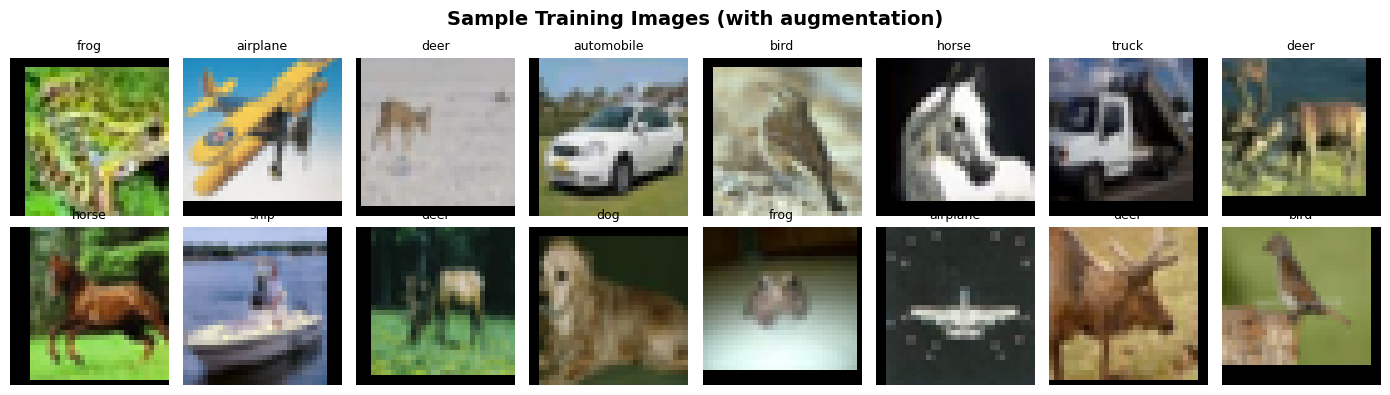

In [6]:
# Visualize a batch of training images
# We need to un-normalize for display
def unnormalize(img_tensor):
    """Reverse CIFAR-10 normalization for visualization."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

# Get a batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample Training Images (with augmentation)', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[labels[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Model

In [7]:
class PatchEmbedding(nn.Module):
    """Convert image into patch embeddings using Conv2d.

    Input:  (B, C, H, W) image tensor
    Output: (B, num_patches, embed_dim) patch embeddings
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=192):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) ** 2

         # Conv2d does patch extraction AND linear projection in one step
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        # x: (B, C, H, W) -> (B, embed_dim, H/P, W/P)
        x = self.projection(x)
        # Flatten spatial dims and transpose: (B, embed_dim, N) -> (B, N, embed_dim)
        x = x.flatten(2).transpose(1, 2)
        return x

In [8]:
# Quick shape test
patch_embed = PatchEmbedding(img_size=32, patch_size=4, embed_dim=192)
dummy_img = torch.randn(2, 3, 32, 32)  # Batch of 2 CIFAR-10 images
patches = patch_embed(dummy_img)
print(f"Input shape:  {dummy_img.shape}")   # (2, 3, 32, 32)
print(f"Output shape: {patches.shape}")      # (2, 64, 192)
print(f"Number of patches: {patch_embed.num_patches}")  # 64
assert patches.shape == (2, 64, 192), "Shape mismatch!"
print("Patch embedding: OK")

Input shape:  torch.Size([2, 3, 32, 32])
Output shape: torch.Size([2, 64, 192])
Number of patches: 64
Patch embedding: OK


In [12]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention built from scratch.

    Each head independently computes Q, K, V projections and attention.
    Heads are concatenated and projected through W_O.
    """
    def __init__(self, embed_dim=192, num_heads=3, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        # Q, K, V projections (combined for efficiency)
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        # Output projection
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x, return_attention=False):
        B, N, D = x.shape
        # Project to Q, K, V and reshape for multi-head
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4) # [3, B, heads, Num_patches, head_dim]
        q, k, v = qkv.unbind(0) # each: (B, heads, N, head_dim)

        # Scaled dot-product attention
        attn_scores = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn_weights = attn_scores.softmax(dim=-1)
        attn_weights = self.attn_drop(attn_weights)

        # Weighted sum of values
        out = (attn_weights @ v)            # (B, heads, N, head_dim)
        out = out.transpose(1, 2).reshape(B, N, D)  # (B, N, D)
        out = self.out_proj(out) # (B, N, D)

        if return_attention:
            return out, attn_weights  # (B, heads, N, N)
        return out, None # (B, N, D)

In [15]:
class TransformerBlock(nn.Module):
    """A single Transformer block with Pre-Norm architecture.

    Pre-Norm: LayerNorm BEFORE attention/MLP (more stable training).
    Uses our from-scratch MultiHeadSelfAttention, not nn.MultiheadAttention.
    """
    def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)

        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x, return_attention=False):
        # Pre-Norm Attention with residual
        attn_output, attn_weights = self.attn(
            self.norm1(x), return_attention=return_attention
        )
        x = x + attn_output

        # Pre-Norm MLP with residual
        x = x + self.mlp(self.norm2(x))

        if return_attention:
            return x, attn_weights  # attn_weights: (B, heads, N, N)
        return x

In [16]:
# Test the Transformer block
block = TransformerBlock(embed_dim=192, num_heads=3)
dummy_tokens = torch.randn(2, 65, 192)  # 64 patches + 1 CLS = 65 tokens

# Without attention weights
out = block(dummy_tokens)
print(f"Input:  {dummy_tokens.shape}")  # (2, 65, 192)
print(f"Output: {out.shape}")           # (2, 65, 192)

# With attention weights
out, attn = block(dummy_tokens, return_attention=True)
print(f"Attention weights: {attn.shape}")  # (2, 3, 65, 65) — per head
print("Transformer block: OK")

Input:  torch.Size([2, 65, 192])
Output: torch.Size([2, 65, 192])
Attention weights: torch.Size([2, 3, 65, 65])
Transformer block: OK


In [27]:
class VisionTransformer(nn.Module):
    """Complete Vision Transformer for image classification."""

    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 num_classes=10, embed_dim=192, depth=6, num_heads=3,
                 mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.depth = depth
        self.num_patches = (img_size // patch_size) ** 2

        # 1. Patch embedding
        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim
        )

        # 2. CLS token and position embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, embed_dim)
        )
        self.pos_drop = nn.Dropout(dropout)

        # 3. Transformer encoder (stack of blocks)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        # 4. Classification head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights following ViT conventions."""
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x, return_attention=False):
        """
        Forward pass of the Vision Transformer.

        Args:
            x: Input images (B, C, H, W)
            return_attention: If True, also return attention weights
                              from the last block

        Returns:
            logits: Class predictions (B, num_classes)
            attn_weights: (optional) Attention from last layer (B, heads, N, N)
        """
        B = x.shape[0]

        # Step 1: Patch embedding — (B, C, H, W) -> (B, num_patches, D)
        x = self.patch_embed(x)

        # Step 2: Prepend CLS token — (B, num_patches, D) -> (B, num_patches+1, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Step 3: Add position embeddings
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Step 4: Pass through Transformer blocks
        attn_weights = None
        for i, block in enumerate(self.blocks):
            if return_attention and i == self.depth - 1:
                # Get attention from the last layer only
                x, attn_weights = block(x, return_attention=True)
            else:
                x = block(x)

        # Step 5: Extract CLS token (index 0)
        cls_output = x[:, 0]  # (B, D)

        # Step 6: Classification head
        cls_output = self.norm(cls_output)
        logits = self.head(cls_output)

        if return_attention:
            return logits, attn_weights
        return logits

In [28]:
# Create the ViT-Tiny model
model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=10,
    embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0, dropout=0.1
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           {total_params * 4 / 1024 / 1024:.1f} MB (float32)")

# Forward pass test
dummy_batch = torch.randn(4, 3, 32, 32).to(device)
logits = model(dummy_batch)
print(f"\nInput shape:  {dummy_batch.shape}")
print(f"Output shape: {logits.shape}")       # Should be (4, 10)
assert logits.shape == (4, 10), "Output shape mismatch!"

# Test with attention weights
logits, attn = model(dummy_batch, return_attention=True)
print(f"Attention shape: {attn.shape}")      # Should be (4, 3, 65, 65)
print("\nFull model: OK! Ready to train.")

Total parameters:     2,693,578
Trainable parameters: 2,693,578
Model size:           10.3 MB (float32)

Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])
Attention shape: torch.Size([4, 3, 65, 65])

Full model: OK! Ready to train.


## TRAIN

In [25]:
# Hyperparameters
EPOCHS = 25
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 5

# Print hyperparameter summary
print("=" * 50)
print("         TRAINING CONFIGURATION")
print("=" * 50)
print(f"  Model:          ViT-Tiny")
print(f"  Parameters:     {total_params:,}")
print(f"  Epochs:         {EPOCHS}")
print(f"  Batch size:     128")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Weight decay:   {WEIGHT_DECAY}")
print(f"  Warmup epochs:  {WARMUP_EPOCHS}")
print(f"  Optimizer:      AdamW")
print(f"  LR schedule:    Linear warmup + Cosine decay")
print(f"  Device:         {device}")
print("=" * 50)

         TRAINING CONFIGURATION
  Model:          ViT-Tiny
  Parameters:     2,693,578
  Epochs:         25
  Batch size:     128
  Learning rate:  0.0003
  Weight decay:   0.05
  Warmup epochs:  5
  Optimizer:      AdamW
  LR schedule:    Linear warmup + Cosine decay
  Device:         cuda


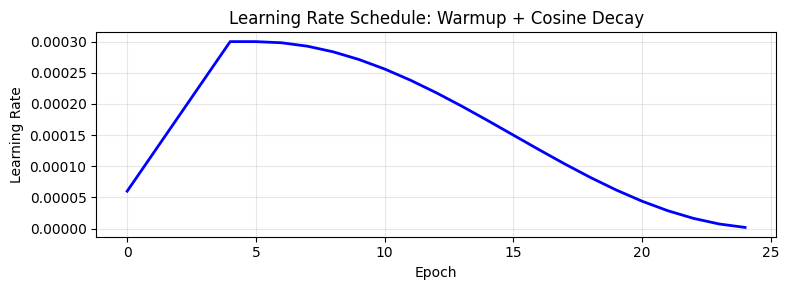

In [26]:
# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
)

# Learning rate scheduler: linear warmup then cosine decay
def lr_lambda(epoch):
    """Linear warmup for warmup_epochs, then cosine decay."""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    else:
        progress = (epoch - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Loss function
criterion = nn.CrossEntropyLoss()

# Visualize the LR schedule
lrs = [lr_lambda(e) * LEARNING_RATE for e in range(EPOCHS)]
plt.figure(figsize=(8, 3))
plt.plot(range(EPOCHS), lrs, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule: Warmup + Cosine Decay')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()
    return running_loss / len(dataloader), 100.0 * correct / total

In [30]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataset. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item()
        predicted = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(dataloader), 100.0 * correct / total

In [31]:
# Fresh model for training
model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3, num_classes=10,
    embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0, dropout=0.1
).to(device)

optimizer = optim.AdamW(
    model.parameters(), lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999)
)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in model.parameters())
print(f"Starting training with {total_params:,} parameters...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>10}")
print("-" * 65)

Starting training with 2,693,578 parameters...
Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
-----------------------------------------------------------------


In [32]:
# Training loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'lr': []
}

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, device
    )

    # Evaluate
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    # Record
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    # Print progress
    print(f"{epoch+1:>5d} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>6.2f}% | {current_lr:>10.6f}")

print(f"\nBest validation accuracy: {max(history['val_acc']):.2f}% "
      f"(epoch {np.argmax(history['val_acc'])+1})")

    1 |     1.8653 |    30.87% |   1.7742 |  35.13% |   0.000120
    2 |     1.6561 |    39.06% |   1.5948 |  42.94% |   0.000180
    3 |     1.4707 |    46.39% |   1.3924 |  50.45% |   0.000240
    4 |     1.3498 |    51.03% |   1.2336 |  56.01% |   0.000300
    5 |     1.2596 |    54.34% |   1.1721 |  57.82% |   0.000300
    6 |     1.1704 |    57.98% |   1.0872 |  60.48% |   0.000298
    7 |     1.1034 |    60.41% |   1.0778 |  61.50% |   0.000293
    8 |     1.0445 |    62.31% |   1.0170 |  63.59% |   0.000284
    9 |     0.9858 |    64.50% |   0.9598 |  65.26% |   0.000271
   10 |     0.9417 |    66.21% |   0.9179 |  67.61% |   0.000256
   11 |     0.8904 |    68.32% |   0.8426 |  70.20% |   0.000238
   12 |     0.8527 |    69.70% |   0.8148 |  71.20% |   0.000218
   13 |     0.8214 |    70.78% |   0.8061 |  71.84% |   0.000196
   14 |     0.7743 |    72.59% |   0.7501 |  73.46% |   0.000173
   15 |     0.7413 |    73.49% |   0.7241 |  74.66% |   0.000150
   16 |     0.7122 |    7

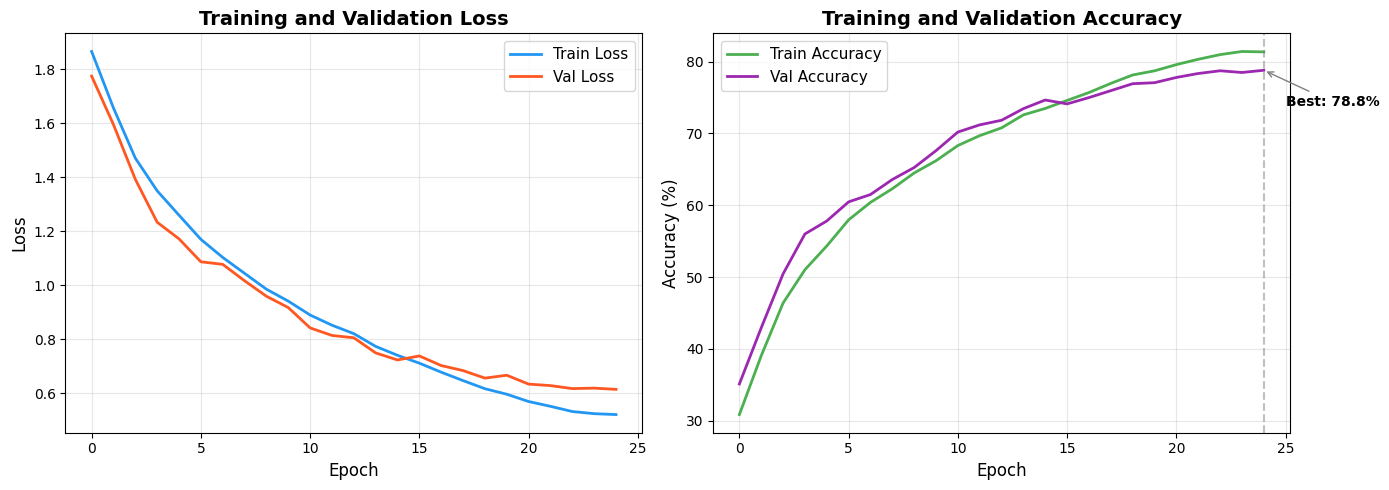

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1 = axes[0]
ax1.plot(history['train_loss'], label='Train Loss', color='#2196F3', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', color='#FF5722', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Accuracy curves
ax2 = axes[1]
ax2.plot(history['train_acc'], label='Train Accuracy', color='#4CAF50', linewidth=2)
ax2.plot(history['val_acc'], label='Val Accuracy', color='#9C27B0', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

best_epoch = np.argmax(history['val_acc'])
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax2.annotate(f"Best: {max(history['val_acc']):.1f}%",
             xy=(best_epoch, max(history['val_acc'])),
             fontsize=10, fontweight='bold',
             xytext=(best_epoch + 1, max(history['val_acc']) - 5),
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()